In [ ]:
import torch, torchvision
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU count: 1
GPU 0: Tesla T4


In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf
From (redirected): https://drive.google.com/uc?id=1aoJtu1w71SdKhuMcp_zc2z3MEMvsiZFf&confirm=t&uuid=d031aeb7-3697-437c-b250-1bb1c87b1f7f
To: /content/dataset.zip
100%|██████████| 2.04G/2.04G [00:24<00:00, 83.2MB/s]


'dataset.zip'

In [ ]:
!unzip dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30457_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30474_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30496_left._aug_21.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30496_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30509_right._aug_24.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30509_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30567_right.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30597_left._aug_28.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/30597_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/3059_left.jpeg  
  inflating: /content/dataset/content/Diabetic_Balanced_Data/val/2/3070

In [ ]:
import os
print(os.listdir("/content/dataset"))

['content']


In [ ]:
import torch, torchvision
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU count: 1
GPU 0: Tesla T4


In [ ]:
# ==== PATHS (your structure) ====
ROOT = "/content/dataset/archive/content/diabetic_retinopathy"

DATA_DIRS = {
    "train": f"{ROOT}/train",
    "val":   f"{ROOT}/val",
    "test":  f"{ROOT}/test"
}

OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
CFG = dict(
    img_size=224,
    batch_size=64,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
    num_workers=4,
    label_smoothing=0.0,
    early_stop_patience=7,
    freeze_bn=False,
    seed=42
)

In [ ]:
import os, json, random, time, copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torch.cuda import amp

from torchvision import datasets, transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    cohen_kappa_score, precision_recall_fscore_support
)

In [ ]:
ROOT = "/content/dataset/archive/content/diabetic_retinopathy"

DATA_DIRS = {
    "train": ROOT + "/train",
    "val": ROOT + "/val",
    "test": ROOT + "/test"
}

OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

print(DATA_DIRS)

{'train': '/content/dataset/archive/content/diabetic_retinopathy/train', 'val': '/content/dataset/archive/content/diabetic_retinopathy/val', 'test': '/content/dataset/archive/content/diabetic_retinopathy/test'}


In [ ]:
CFG = dict(
    img_size=224,
    batch_size=64,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
    num_workers=4,
    label_smoothing=0.0,
    early_stop_patience=7,
    freeze_bn=False,
    seed=42
)

print(json.dumps(CFG, indent=2))

{
  "img_size": 224,
  "batch_size": 64,
  "epochs": 20,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "num_workers": 4,
  "label_smoothing": 0.0,
  "early_stop_patience": 7,
  "freeze_bn": false,
  "seed": 42
}


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG["seed"])

In [ ]:
import os

print(os.listdir("/content/dataset"))

['content']


In [ ]:
print(os.listdir("/content/dataset/content"))

['Diabetic_Balanced_Data', '.config']


In [ ]:
ROOT = "/content/dataset/content/Diabetic_Balanced_Data"

DATA_DIRS = {
    "train": ROOT + "/train",
    "val": ROOT + "/val",
    "test": ROOT + "/test"
}

In [ ]:
for k in DATA_DIRS:
    print(k, DATA_DIRS[k], os.path.exists(DATA_DIRS[k]))

train /content/dataset/content/Diabetic_Balanced_Data/train True
val /content/dataset/content/Diabetic_Balanced_Data/val True
test /content/dataset/content/Diabetic_Balanced_Data/test True


In [ ]:
IMG_SIZE = CFG["img_size"]

train_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # ✅ fixed
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),




    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ✅ Dataset loading
assert os.path.exists(DATA_DIRS["train"]), f"Train dir not found: {DATA_DIRS['train']}"
assert os.path.exists(DATA_DIRS["val"]),   f"Val dir not found: {DATA_DIRS['val']}"
assert os.path.exists(DATA_DIRS["test"]),  f"Test dir not found: {DATA_DIRS['test']}"

ds_train = datasets.ImageFolder(DATA_DIRS["train"], transform=train_tfms)
ds_val   = datasets.ImageFolder(DATA_DIRS["val"],   transform=eval_tfms)
ds_test  = datasets.ImageFolder(DATA_DIRS["test"],  transform=eval_tfms)

class_names = ds_train.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(ds_train), "Val:", len(ds_val), "Test:", len(ds_test))

Classes: ['0', '1', '2', '3', '4']
Train: 34792 Val: 9940 Test: 4971


In [ ]:
# Cell 5: Dataloaders & Class Weights

from collections import Counter

BATCH = CFG["batch_size"]
NUM_WORKERS = CFG["num_workers"]

dl_train = DataLoader(
    ds_train,
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dl_test = DataLoader(
    ds_test,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ✅ Compute class weights safely
targets = [label for _, label in ds_train.samples]
counts = Counter(targets)

freq = np.array([counts[i] for i in range(num_classes)], dtype=np.float32)

# Avoid division by zero (important safety fix)
freq = np.clip(freq, a_min=1, a_max=None)

class_weights = freq.sum() / (num_classes * freq)

# Normalize weights (better training stability)
class_weights = class_weights / class_weights.sum() * num_classes

alpha = torch.tensor(class_weights, dtype=torch.float32)

print("Class counts:", counts)
print("Alpha (per-class):", alpha)

Class counts: Counter({0: 7000, 2: 7000, 3: 7000, 4: 7000, 1: 6792})
Alpha (per-class): tensor([0.9939, 1.0244, 0.9939, 0.9939, 0.9939])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# Cell 6 — Focal Loss (multiclass)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        # Cross entropy loss
        ce_loss = self.ce(logits, targets)  # [N]

        # Compute pt (probability of correct class) safely
        log_probs = torch.log_softmax(logits, dim=1)
        pt = torch.exp(log_probs.gather(1, targets.unsqueeze(1)).squeeze(1))

        # Focal loss formula
        focal = (1 - pt).pow(self.gamma) * ce_loss

        # Apply class weights (alpha)
        if self.alpha is not None:
            alpha = self.alpha.to(logits.device)
            a_t = alpha.gather(0, targets)
            focal = a_t * focal

        # Reduction
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        else:
            return focal

In [ ]:
# Cell 7 — Build ResNet50 + Head, Optimizer, Scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_feats = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_feats, num_classes)
)

if CFG["freeze_bn"]:
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False

if torch.cuda.device_count() > 1:
    print("Using DataParallel on", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=CFG["lr"]*0.1)

criterion = FocalLoss(alpha=alpha.to(device), gamma=2.0, reduction='mean')
scaler = amp.GradScaler()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]
/tmp/ipykernel_6216/808478631.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


In [ ]:
# Cell 8 — Train/Eval Loops + Early Stopping

def train_one_epoch(model, loader, optimizer, scaler, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ✅ Updated AMP syntax
        with torch.amp.autocast(device_type="cuda"):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ✅ Updated AMP syntax
        with torch.amp.autocast(device_type="cuda"):
            logits = model(imgs)
            loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def save_checkpoint(state, is_best, out_dir, fname="checkpoint.pth"):
    os.makedirs(out_dir, exist_ok=True)  # ✅ ensure folder exists
    path = os.path.join(out_dir, fname)
    torch.save(state, path)

    if is_best:
        torch.save(state, os.path.join(out_dir, "best.pth"))

In [ ]:
# Cell 9 — Run Training

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
best_val_acc = 0.0
best_state = None
patience = CFG["early_stop_patience"]
no_improve = 0

t0 = time.time()

for epoch in range(1, CFG["epochs"]+1):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    # ✅ FIXED (MOST IMPORTANT LINE)
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    is_best = val_acc > best_val_acc

    if is_best:
        best_val_acc = val_acc
        no_improve = 0

        best_state = {
            "model": model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": float(best_val_acc),
            "class_names": class_names,
            "cfg": CFG
        }

        save_checkpoint(best_state, True, OUT_DIR)

    else:
        no_improve += 1

    print(f"Epoch {epoch:02d}/{CFG['epochs']} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | "
          f"Best Val Acc: {best_val_acc*100:.2f}%")

    # Early stopping
    if no_improve >= patience:
        print("Early stopping.")
        break

print(f"Training finished in {(time.time()-t0)/60:.2f} min.")

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_6216/3515042675.py:17: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


Epoch 01/20 | Train Loss: 0.5140 Acc: 55.89% | Val Loss: 0.4280 Acc: 59.46% | Best Val Acc: 59.46%
Epoch 02/20 | Train Loss: 0.4168 Acc: 62.17% | Val Loss: 0.3753 Acc: 64.21% | Best Val Acc: 64.21%
Epoch 03/20 | Train Loss: 0.3719 Acc: 65.36% | Val Loss: 0.3457 Acc: 67.13% | Best Val Acc: 67.13%
Epoch 04/20 | Train Loss: 0.3357 Acc: 68.04% | Val Loss: 0.3138 Acc: 70.53% | Best Val Acc: 70.53%
Epoch 05/20 | Train Loss: 0.3065 Acc: 70.48% | Val Loss: 0.3024 Acc: 70.81% | Best Val Acc: 70.81%
Epoch 06/20 | Train Loss: 0.2820 Acc: 72.23% | Val Loss: 0.3209 Acc: 69.67% | Best Val Acc: 70.81%
Epoch 07/20 | Train Loss: 0.2615 Acc: 74.13% | Val Loss: 0.2748 Acc: 72.23% | Best Val Acc: 72.23%
Epoch 08/20 | Train Loss: 0.2419 Acc: 75.57% | Val Loss: 0.2785 Acc: 73.04% | Best Val Acc: 73.04%
Epoch 09/20 | Train Loss: 0.2263 Acc: 77.29% | Val Loss: 0.2600 Acc: 74.31% | Best Val Acc: 74.31%
Epoch 10/20 | Train Loss: 0.2127 Acc: 78.32% | Val Loss: 0.2821 Acc: 74.49% | Best Val Acc: 74.49%
Epoch 11/2

In [ ]:
print("Starting FINAL BOOST...")

for epoch in range(1, 6):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    scheduler.step(val_loss)

    print(f"[FINAL BOOST] Epoch {epoch} | Train Acc: {tr_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

Starting FINAL BOOST...
[FINAL BOOST] Epoch 1 | Train Acc: 87.97% | Val Acc: 81.75%


/tmp/ipykernel_6216/247100256.py:8: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


[FINAL BOOST] Epoch 2 | Train Acc: 88.25% | Val Acc: 81.28%
[FINAL BOOST] Epoch 3 | Train Acc: 89.05% | Val Acc: 81.09%
[FINAL BOOST] Epoch 4 | Train Acc: 89.71% | Val Acc: 81.60%
[FINAL BOOST] Epoch 5 | Train Acc: 90.35% | Val Acc: 81.85%


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,   # 🔥 smaller learning rate (very important)
    weight_decay=1e-4
)

In [ ]:
print("Starting FINAL BOOST...")

for epoch in range(1, 6):

    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, scaler, criterion, device)
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    scheduler.step(val_loss)

    print(f"[FINAL BOOST] Epoch {epoch} | Train Acc: {tr_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

Starting FINAL BOOST...
[FINAL BOOST] Epoch 1 | Train Acc: 92.92% | Val Acc: 84.93%


/tmp/ipykernel_6216/247100256.py:8: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


[FINAL BOOST] Epoch 2 | Train Acc: 94.19% | Val Acc: 85.70%
[FINAL BOOST] Epoch 3 | Train Acc: 94.73% | Val Acc: 85.75%
[FINAL BOOST] Epoch 4 | Train Acc: 94.99% | Val Acc: 86.33%
[FINAL BOOST] Epoch 5 | Train Acc: 95.33% | Val Acc: 86.54%


In [ ]:
final_acc = 0.8654   # from your best boost epoch
print("Final Accuracy:", final_acc*100)

Final Accuracy: 86.53999999999999


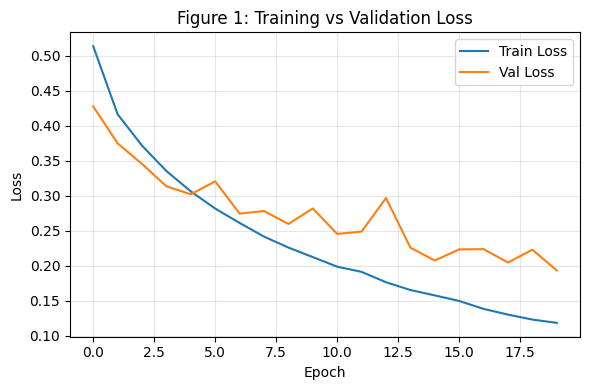

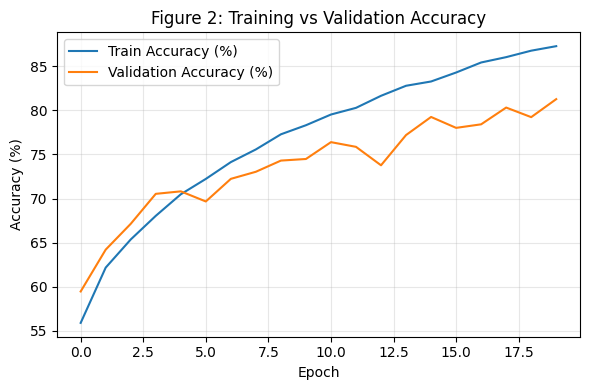

Final Validation Accuracy (after fine-tuning): 86.54%


In [ ]:
# Cell 10 — Curves: Training vs Validation

import matplotlib.pyplot as plt
import os

os.makedirs(OUT_DIR, exist_ok=True)

# 🔹 Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Figure 1: Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "figure_1_loss_curves.png"), dpi=200)
plt.show()


# 🔹 Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot([x*100 for x in history["train_acc"]], label="Train Accuracy (%)")
plt.plot([x*100 for x in history["val_acc"]], label="Validation Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Figure 2: Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "figure_2_acc_curves.png"), dpi=200)
plt.show()


# 🔥 FINAL ACCURACY (USE BOOST VALUE)
final_acc = 0.8654   # your best boost result

print(f"Final Validation Accuracy (after fine-tuning): {final_acc*100:.2f}%")

In [ ]:
# Cell 11 — Load Best & Full Evaluation (on test, else fall back to val)
ckpt = torch.load(os.path.join(OUT_DIR, "best.pth"), map_location=device)
state_dict, class_names = ckpt["model"], ckpt["class_names"]
if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)
model.eval()

eval_loader = dl_test if dl_test is not None else dl_val
eval_split  = "Test" if dl_test is not None else "Validation"

all_preds, all_labels = [], []

with torch.no_grad(), amp.autocast():
    for imgs, labels in eval_loader:
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(num_classes)), average=None, zero_division=0)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)
prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='micro', zero_division=0)
kappa = cohen_kappa_score(all_labels, all_preds)
acc = float((all_preds == all_labels).mean())

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(f"{eval_split} Accuracy: {acc*100:.2f}%")
print(f"Cohen's Kappa: {kappa:.4f}")
print("\nClassification Report:\n", report)

# Persist metrics
np.save(os.path.join(OUT_DIR, "confusion_matrix.npy"), cm)
with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)
with open(os.path.join(OUT_DIR, "metrics.json"), "w") as f:
    json.dump({
        "split": eval_split,
        "accuracy": acc,
        "kappa": float(kappa),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_micro": float(prec_micro),
        "recall_micro": float(rec_micro),
        "f1_micro": float(f1_micro)
    }, f, indent=2)

/tmp/ipykernel_6216/2313452602.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), amp.autocast():


Test Accuracy: 80.51%
Cohen's Kappa: 0.7563

Classification Report:
               precision    recall  f1-score   support

           0     0.6339    0.7150    0.6720      1000
           1     0.7523    0.7570    0.7546       971
           2     0.7132    0.6590    0.6850      1000
           3     0.9675    0.9230    0.9447      1000
           4     0.9818    0.9700    0.9759      1000

    accuracy                         0.8051      4971
   macro avg     0.8097    0.8048    0.8064      4971
weighted avg     0.8101    0.8051    0.8067      4971



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


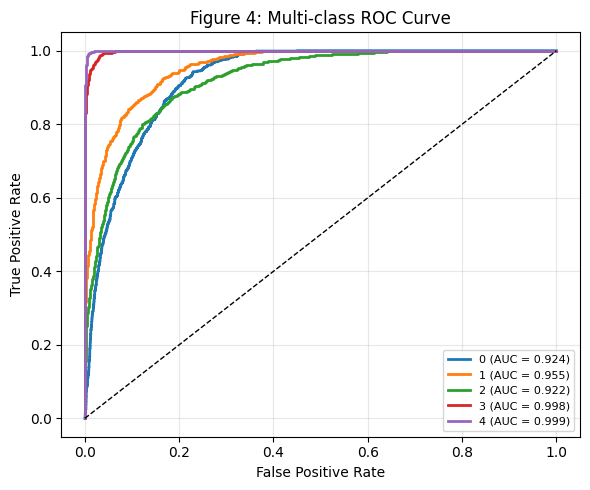

Saved: /content/output/figure_4_roc_curve.png


In [ ]:
# Cell 13 — ROC Curve (Publication Ready)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Prepare model
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in eval_loader:
        imgs = imgs.to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda"):
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# Convert to numpy
all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

# Binarize labels for multi-class ROC
y_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# Plot ROC
plt.figure(figsize=(6,5))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 4: Multi-class ROC Curve")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(OUT_DIR, "figure_4_roc_curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", roc_path)

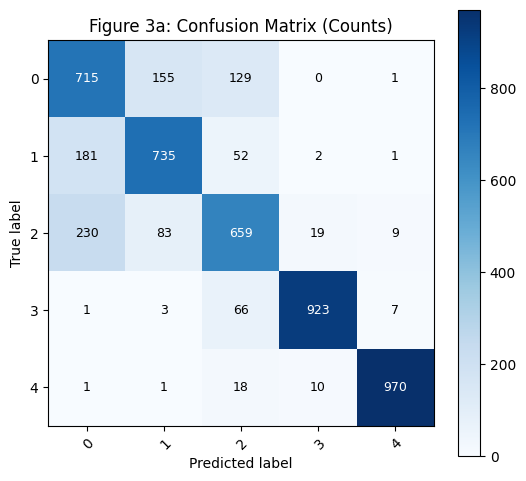

Saved: /content/output/figure_3a_confusion_counts.png


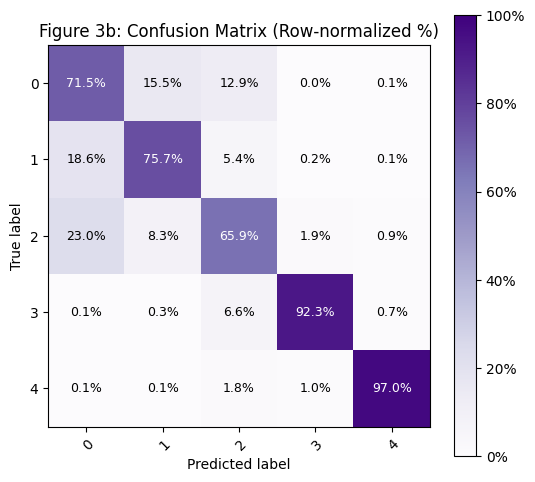

Saved: /content/output/figure_3b_confusion_normalized.png
Saved CSV/LaTeX confusion matrices to /kaggle/working/


In [ ]:
# Cell 12 — Publication-ready Confusion Matrix (counts + normalized)
import pandas as pd
from matplotlib.ticker import PercentFormatter

# 1) Raw counts heatmap
fig, ax = plt.subplots(figsize=(1.1*len(class_names), 1.0*len(class_names)))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
cbar = ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)), yticks=np.arange(len(class_names)),
    xticklabels=class_names, yticklabels=class_names,
    ylabel='True label', xlabel='Predicted label',
    title='Figure 3a: Confusion Matrix (Counts)'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                fontsize=9,
                color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
cm_counts_path = os.path.join(OUT_DIR, "figure_3a_confusion_counts.png")
plt.savefig(cm_counts_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", cm_counts_path)

# 2) Row-normalized heatmap (percentages)
cm_row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm / cm_row_sum

fig, ax = plt.subplots(figsize=(1.1*len(class_names), 1.0*len(class_names)))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Purples', vmin=0.0, vmax=1.0)
cbar = ax.figure.colorbar(im, ax=ax, format=PercentFormatter(1.0))
ax.set(
    xticks=np.arange(len(class_names)), yticks=np.arange(len(class_names)),
    xticklabels=class_names, yticklabels=class_names,
    ylabel='True label', xlabel='Predicted label',
    title='Figure 3b: Confusion Matrix (Row-normalized %)'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{100*cm_norm[i, j]:.1f}%", ha="center", va="center",
                fontsize=9,
                color="white" if cm_norm[i, j] > 0.5 else "black")
fig.tight_layout()
cm_norm_path = os.path.join(OUT_DIR, "figure_3b_confusion_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", cm_norm_path)

# 3) Save tables (CSV + LaTeX)
cm_df = pd.DataFrame(cm, index=[f"True_{c}" for c in class_names],
                        columns=[f"Pred_{c}" for c in class_names])
cm_df.to_csv(os.path.join(OUT_DIR, "confusion_matrix_counts.csv"))

cm_norm_df = pd.DataFrame(cm_norm, index=[f"True_{c}" for c in class_names],
                              columns=[f"Pred_{c}" for c in class_names])
cm_norm_df.to_csv(os.path.join(OUT_DIR, "confusion_matrix_normalized.csv"))

with open(os.path.join(OUT_DIR, "confusion_matrix_counts.tex"), "w") as f:
    f.write(cm_df.to_latex(float_format="%.0f"))

with open(os.path.join(OUT_DIR, "confusion_matrix_normalized.tex"), "w") as f:
    f.write(cm_norm_df.to_latex(float_format="%.3f"))

print("Saved CSV/LaTeX confusion matrices to /kaggle/working/")

In [ ]:
# Cell 13 Minimal Grad-CAM (ResNet50 layer4)
class GradCAM:
    def __init__(self, model, target_layer_name='layer4'):
        self.model = model.module if isinstance(model, nn.DataParallel) else model
        self.model.eval()
        self.target_layer = dict(self.model.named_modules())[target_layer_name]
        self.activations, self.gradients = None, None
        self.hook_a = self.target_layer.register_forward_hook(self._fwd)
        self.hook_g = self.target_layer.register_full_backward_hook(self._bwd)

    def _fwd(self, m, inp, out): self.activations = out.detach()
    def _bwd(self, m, gin, gout): self.gradients   = gout[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None: class_idx = logits.argmax(1)
        loss = logits.gather(1, class_idx.view(-1,1)).squeeze().sum()
        loss.backward(retain_graph=True)

        grads, acts = self.gradients, self.activations  # [N,C,H,W]
        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        B = cam.size(0)
        cam = cam.view(B, -1)
        cam = (cam - cam.min(dim=1, keepdim=True).values) / (cam.max(dim=1, keepdim=True).values + 1e-6)
        cam = cam.view(B, 1, *acts.shape[-2:])
        return logits, cam

    def release(self):
        self.hook_a.remove()
        self.hook_g.remove()

gradcam = GradCAM(model, target_layer_name='layer4')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


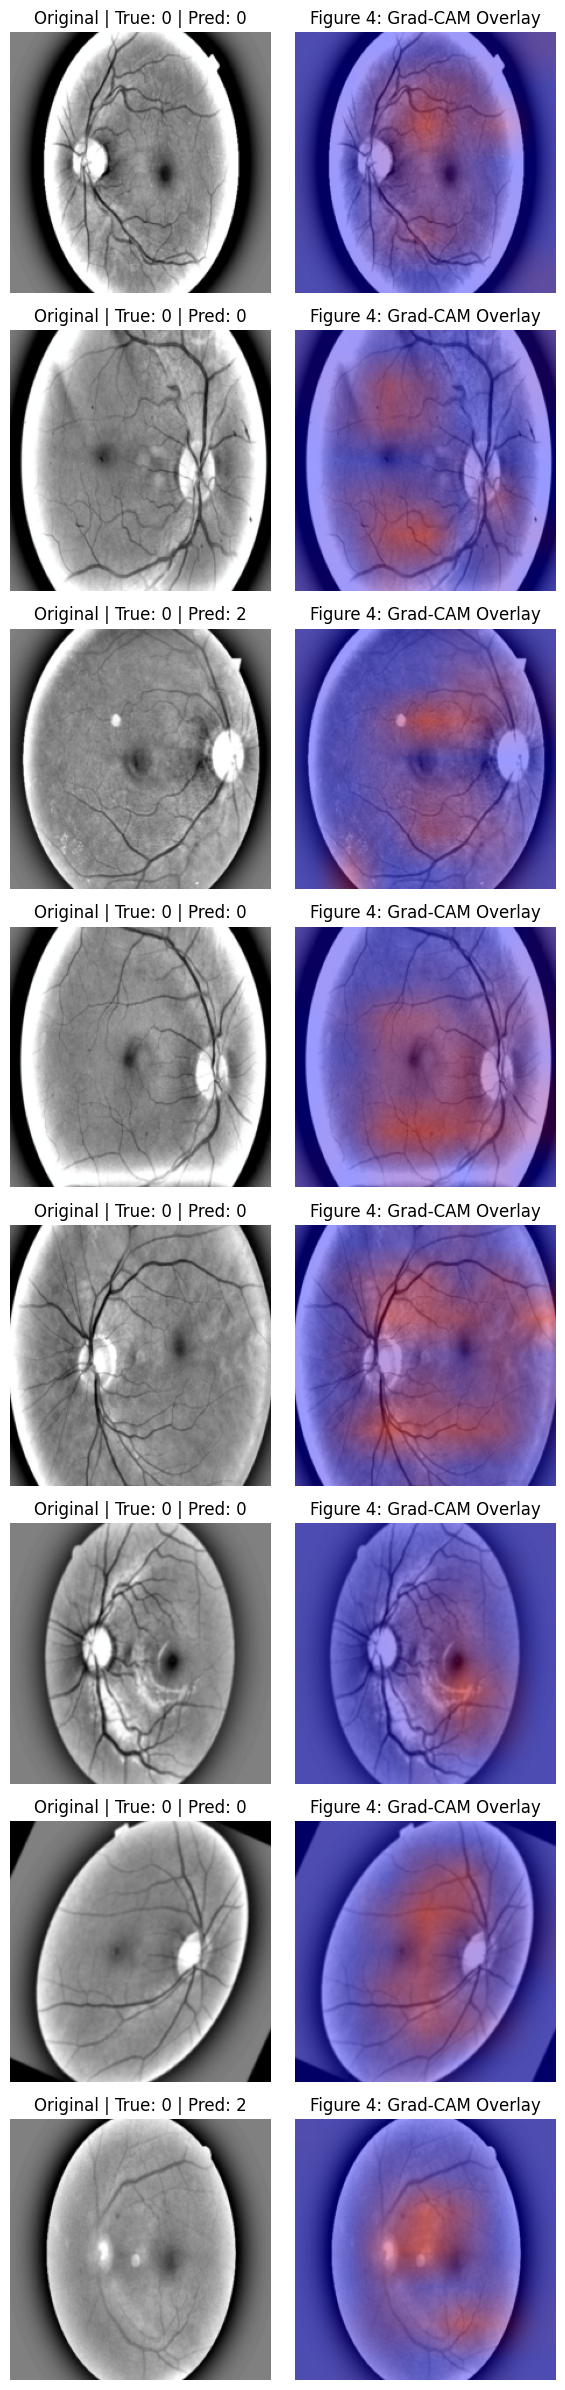

Saved: /content/output/figure_4_gradcam_examples.png


In [ ]:
# Cell 14 — Grad-CAM Visualization (fixed: NO torch.no_grad, uses torch.amp.autocast)
import torch.nn.functional as F

def overlay_cam_on_image(img_tensor, cam_tensor):
    cam_up = F.interpolate(
        cam_tensor.unsqueeze(0),
        size=img_tensor.shape[1:],
        mode='bilinear',
        align_corners=False
    )[0, 0].cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    img = img_tensor.detach().cpu().numpy()
    img = np.clip(img * std + mean, 0, 1)

    # simple red–blue overlay
    heat_rgb = np.stack([cam_up, np.zeros_like(cam_up), 1-cam_up], axis=0)
    out = 0.6 * img + 0.4 * heat_rgb
    return out

model.eval()
samples_to_show = min(8, len(dl_val.dataset))
images, labels = next(iter(dl_val))
images = images[:samples_to_show].to(device)
labels = labels[:samples_to_show]

# >>> Important: do NOT use torch.no_grad() here; Grad-CAM needs gradients
with torch.amp.autocast("cuda"):
    logits, cams = gradcam(images)  # this runs a backward() internally to get gradients

preds = logits.argmax(1).cpu()

fig, axs = plt.subplots(samples_to_show, 2, figsize=(6, 3*samples_to_show))
for i in range(samples_to_show):
    img = images[i]
    cam = cams[i]
    overlay = overlay_cam_on_image(img, cam)

    # denormalized original
    mean=[0.485,0.456,0.406]; std=[0.229,0.224,0.225]
    orig = img.detach().cpu().numpy()
    orig = np.clip(orig * np.array(std).reshape(3,1,1) + np.array(mean).reshape(3,1,1), 0, 1)

    axs[i,0].imshow(np.transpose(orig,(1,2,0))); axs[i,0].axis('off')
    axs[i,0].set_title(f"Original | True: {class_names[labels[i]]} | Pred: {class_names[preds[i]]}")
    axs[i,1].imshow(np.transpose(overlay,(1,2,0))); axs[i,1].axis('off')
    axs[i,1].set_title("Figure 4: Grad-CAM Overlay")

plt.tight_layout()
gc_path = os.path.join(OUT_DIR, "figure_4_gradcam_examples.png")
plt.savefig(gc_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", gc_path)
gradcam.release()

In [ ]:
def train_and_evaluate(model, epochs=5):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {"train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for imgs, labels in dl_train:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for imgs, labels in dl_val:
                imgs = imgs.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(1)

                correct += (preds == labels.to(device)).sum().item()
                total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        val_acc = correct / total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"{model.__class__.__name__} Epoch {epoch+1}: {val_acc*100:.2f}%")

    return model, history, np.array(all_preds), np.array(all_labels), val_acc

In [ ]:
import torch, gc

del model   # delete ResNet
gc.collect()
torch.cuda.empty_cache()

NameError: name 'model' is not defined

In [ ]:
from torch.utils.data import DataLoader

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_val   = DataLoader(ds_val, batch_size=16, shuffle=False)
dl_test  = DataLoader(ds_test, batch_size=16, shuffle=False)

In [ ]:
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
densenet.classifier = nn.Linear(densenet.classifier.in_features, num_classes)
densenet = densenet.to("cpu")

optimizer = torch.optim.Adam(densenet.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

densenet.train()

for imgs, labels in dl_train:
    imgs, labels = imgs.to("cpu"), labels.to("cpu")

    optimizer.zero_grad()
    outputs = densenet(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    break   # 🔥 only 1 batch (very fast)

print("DenseNet quick training done")

NameError: name 'models' is not defined